In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df_fraud = pd.read_csv(r"C:\Users\Student\Downloads\OISIS ONLYBYTE\credit_card_fraud_10k.csv")
df_fraud

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [3]:
df_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [4]:
# Check class distribution
fraud_counts = df_fraud['is_fraud'].value_counts()
print("\nClass distribution:")
print(fraud_counts)


Class distribution:
is_fraud
0    9849
1     151
Name: count, dtype: int64


In [5]:
fraud_percentage = fraud_counts[1] / len(df_fraud) * 100 
print(f"\nPercentage of fraudulant transections: {fraud_percentage:.4f}%")


Percentage of fraudulant transections: 1.5100%


# Distribution of amount and time of day

In [6]:
# Separating froud and non froud 
fraud = df_fraud[df_fraud['is_fraud'] == 1 ]
non_fraud = df_fraud[df_fraud['is_fraud'] == 0]

# Amount Distribution

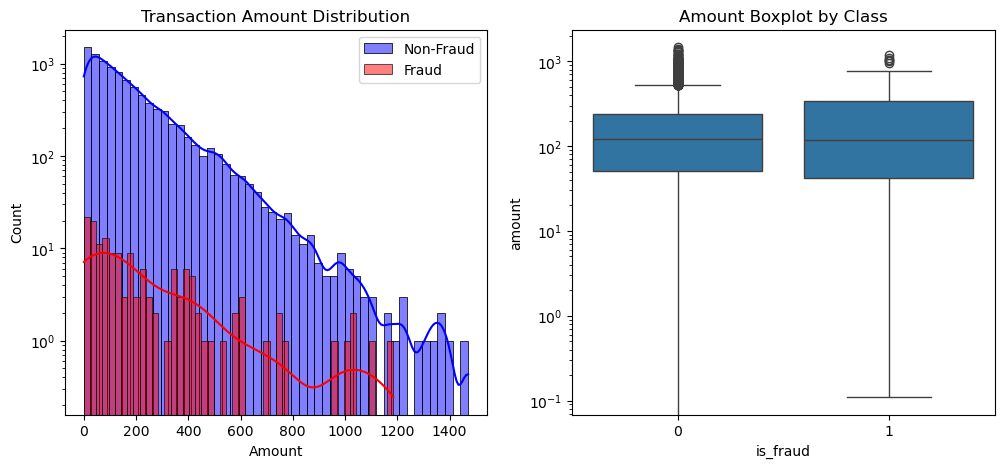

In [7]:
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
sns.histplot(non_fraud['amount'], bins = 50, color = 'blue', label = 'Non-Fraud', kde=True)
sns.histplot(fraud['amount'], bins = 50, color ='red', label = 'Fraud', kde = True)
plt.yscale('log') # To see both
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(x = 'is_fraud', y = 'amount', data = df_fraud)
plt.yscale('log')
plt.title('Amount Boxplot by Class')
plt.show()

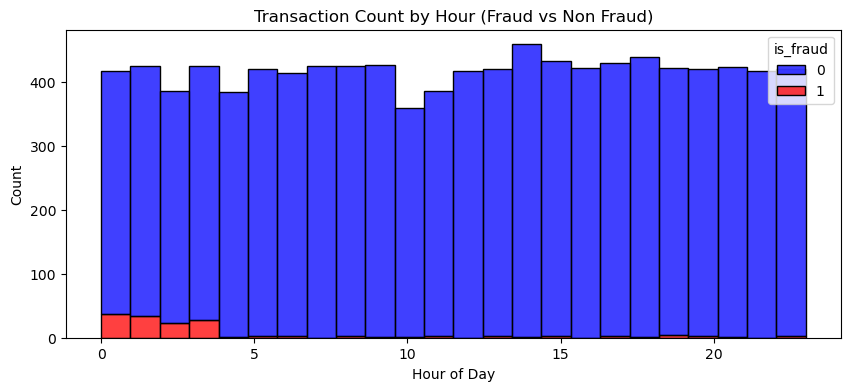

In [8]:
# Time of day analysis 
plt.figure(figsize = (10,4))
sns.histplot(data = df_fraud, x = 'transaction_hour', hue = 'is_fraud', bins = 24, multiple = 'stack', palette = ['blue', 'red'])
plt.title('Transaction Count by Hour (Fraud vs Non Fraud)')
plt.xlabel('Hour of Day')
plt.show()

# Why Standard accuracy is misleading 

## Accuracy is misleading in imbalanced datasets because it gives high scores even when the model fails to detect the minority class. For example if only 0.17% of transections are fraud, a model that predicts everything as non fraud achievs 99,83% accuracy but catches zero fraudes. In fraud detection, the cost of missing a fraud (false negative) is huge, so we need metrics like Recall (Sensitivity) and precision that focuse on the positive class. Accuracy ignores the actual performance on the rare class, making it useless here.

# Applaying the class imbalance hsndling technique
## We will use SMOTE (oversampling) and also class_weight = 'balanced' for Logistic Regression as a comparison. 

In [9]:
# Separating features and target 
x = df_fraud.drop(['is_fraud','transaction_hour', 'merchant_category'], axis = 1 )
y = df_fraud['is_fraud']


 # Scale 'amount' (and possible other features if needed)
scaler = StandardScaler()
x['amount'] = scaler.fit_transform(x[['amount']])# We oly scale the amount, other v features are already scaled


# Train_test_split with stratification (ensures fraud appears in bouth sets)
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size = 0.3, random_state = 42, stratify =  y)

print ("Train fraud ratio:", y_train.mean())
print("Test fraud ratio:", y_test.mean())

Train fraud ratio: 0.015142857142857144
Test fraud ratio: 0.015


In [10]:
# Now let us apply SMOTE on the training set (only, never on test set)

smote = SMOTE(random_state = 42)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)
print("After SMOTE:")
print(pd.Series(y_train_sm).value_counts())

After SMOTE:
is_fraud
0    6894
1    6894
Name: count, dtype: int64


# We will train at least 2 models 
## We will train Logistic Regression (with class_weight = 'balanced') and Random Forest ( which handles imbalance better, but we will also use SMOTE fro it). We can replace Random Forest with Decision Tree or XGBoost 

In [11]:
#Defining the model
models = {'Logistic Regression': LogisticRegression(class_weight = 'balanced', random_state = 42, max_iter = 1000), 'Random Forest': RandomForestClassifier(random_state = 42, n_estimators = 100)}

## For models that benefit from SMOTE, we will train oversampled data
## We will keep LR on original with class_weight, and RF on Smote data

In [12]:
# Train LR on original (with class_weight)
lr = models['Logistic Regression']
lr.fit(x_train_sm, y_train_sm)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
# Train RF on SMOTE
rf = models['Random Forest']
rf.fit(x_train_sm, y_train_sm) 

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Evaluation using Precision, Recall, F1, AUC-ROC


Logistic Regression Result:
Accuracy: 0.8093333333333333
Recall: 1.0
F1 Score: 0.13595166163141995
Precision_score: 0.07293354943273905
AUC-ROC: 0.9721752209061854


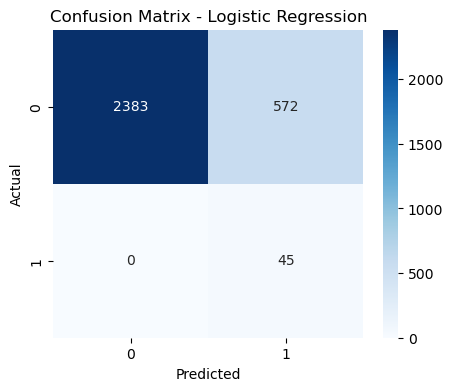

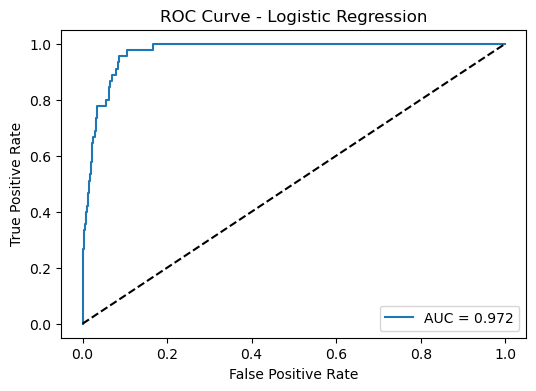


Random Forest Result:
Accuracy: 0.954
Recall: 0.6444444444444445
F1 Score: 0.29591836734693877
Precision_score: 0.19205298013245034
AUC-ROC: 0.9389058093626621


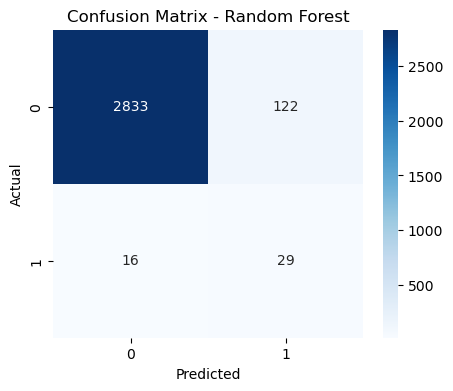

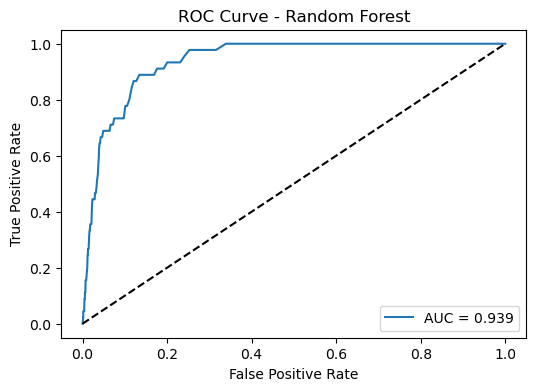

In [16]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

def evaluation_model(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    print(f"\n{model_name} Result:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Precision_score:", precision_score(y_test, y_pred))
    
    if y_proba is not None:
        print("AUC-ROC:", roc_auc_score(y_test, y_proba))
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred) 
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix - {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
        
        #ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
        plt.plot([0,1],[0,1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {model_name}')
        plt.legend()
        plt.show()

# CALLIng the function 
evaluation_model(lr, x_test, y_test, "Logistic Regression") 
evaluation_model(rf, x_test, y_test, "Random Forest")

# In fraude detection, Recall(True Positives / (True Positives + False Negatives)) is not often more important than Precision (False Negative) has a high cost (financial loss, customer sissatisfaction). However too low Precision means many false alarms, which wastes investigation resources. The ideal is to maximise Recall while keeping Precision accepted. Often a business will choose a threshold based on the cost of false positive sv. false negatives. The F1 score balances both, but Recall is the primary metric when the cost of missing fraud is high. The AUC-ROC is also crucial because it shows the model's ability to separate classes across all thresholds, independent of a specific cutoff